In [1]:
import utils_FaIR_JAX
import utils_inverse
import jax
import matplotlib.pyplot as plt
import numpy as np


## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

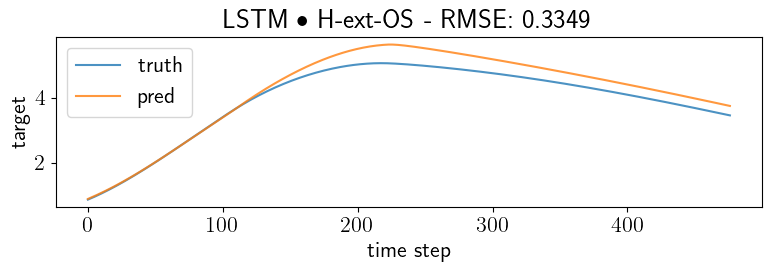

In [90]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True)
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "All": emis_dict_calib_JAX
}

emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_test_JAX)
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 1
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

In [91]:
paramsK_base, baseline_results, baseline_preds, ground_truth = utils_inverse.evaluate_baseline_over_multiple_tests(
    emis_dict_train=emis_dict_tier1_JAX,
    test_sets=test_sets,
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden=32,
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

In [94]:
for test_set in baseline_results:
    if (test_set == 'Tier 2' or test_set == 'CS3') and 'historical' in baseline_results[test_set]:
        baseline_results[test_set].pop('historical')
    per_scen = baseline_results[test_set]
    mean_err = baseline_results[test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0320
  historical                      0.0498
  H-ext                           0.0193
  M                               0.0134
  ML                              0.0157
  L                               0.0442
  VLLO-ext                        0.0417
  VLHO                            0.0399

Tier 2 mean scaled RMSE: 0.0627
  H-ext-OS                        0.0661
  M-ext                           0.0728
  ML-ext                          0.0882
  L-ext                           0.0262
  VLHO-ext                        0.0728

DECK mean scaled RMSE: 0.0525
  abrupt-4xCO2                    0.0600
  1pctCO2                         0.0449

CS3 mean scaled RMSE: 0.0716
  AA                              0.1089
  CT                              0.0296

All mean scaled RMSE: 0.0468
  historical                      0.0498
  H-ext                           0.0193
  M                               0.0134
  ML                              0.0157
  L                    

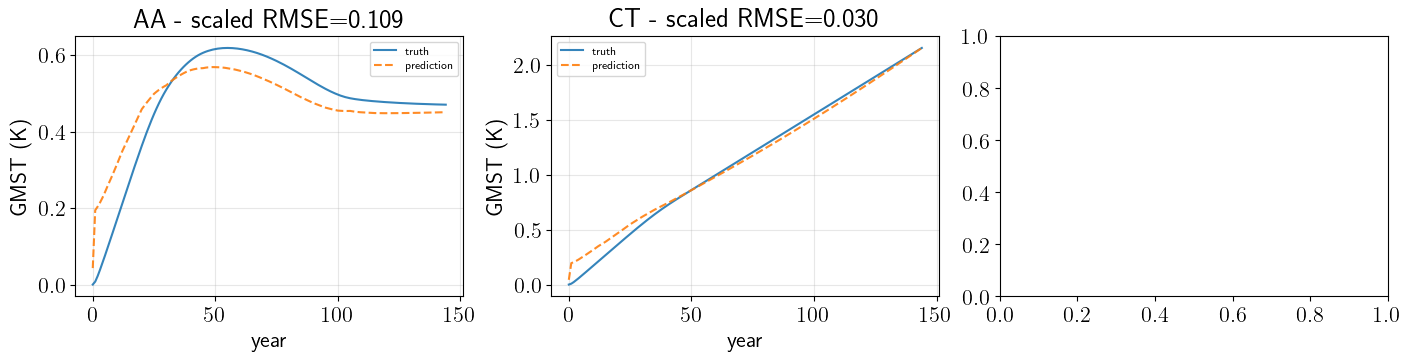

In [95]:
test_set = 'CS3'
N_scens = len(baseline_results[test_set])
rows = int(np.ceil(N_scens / 3))
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5*rows), constrained_layout=True)
axes = axes.ravel()

for i, scen in enumerate(baseline_results[test_set]):
    if scen == 'mean':
        continue
    ax = axes[i]
    ax.plot(ground_truth[test_set][scen],  label="truth", alpha=0.9)
    ax.plot(baseline_preds[test_set][scen],  label="prediction", ls="--", alpha=0.9)
    ax.set_title(f"{scen} - scaled RMSE={baseline_results[test_set][scen]:.3f}")
    ax.set_xlabel("year")
    ax.set_ylabel("GMST (K)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

In [96]:
training_paths = ['checkpoints/co2/inverse_constant_tier1_co2_only.pkl',
                  'checkpoints/co2/inverse_constant_tier2_co2_only.pkl',
                  'checkpoints/co2/inverse_constant_DECK_co2_only.pkl',
                  'checkpoints/co2/inverse_constant_all_co2_only.pkl']
optimal_results = utils_inverse.evaluate_optimal_emulator(
    training_paths=training_paths,
    test_sets=test_sets,
    params0=params0,
    active_agents=('CO2'),
    inactive_mode="zeros",
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden=32,
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

In [97]:
for test_set in optimal_results[training_paths[0]]['metrics']:
    if (test_set == 'Tier 2' or test_set == 'CS3') and 'historical' in optimal_results[training_paths[0]]['metrics'][test_set]:
        optimal_results[training_paths[0]]['metrics'][test_set].pop('historical')
    per_scen = optimal_results[training_paths[0]]['metrics'][test_set]
    mean_err = optimal_results[training_paths[0]]['metrics'][test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0264
  historical                      0.0095
  H-ext                           0.0332
  M                               0.0159
  ML                              0.0165
  L                               0.0627
  VLLO-ext                        0.0286
  VLHO                            0.0184

Tier 2 mean scaled RMSE: 0.0549
  H-ext-OS                        0.0526
  M-ext                           0.0701
  ML-ext                          0.1155
  L-ext                           0.0591
  VLHO-ext                        0.0222

DECK mean scaled RMSE: 0.0596
  abrupt-4xCO2                    0.0723
  1pctCO2                         0.0469

CS3 mean scaled RMSE: 0.0393
  AA                              0.0790
  CT                              0.0288

All mean scaled RMSE: 0.0445
  historical                      0.0095
  H-ext                           0.0332
  M                               0.0159
  ML                              0.0165
  L                    

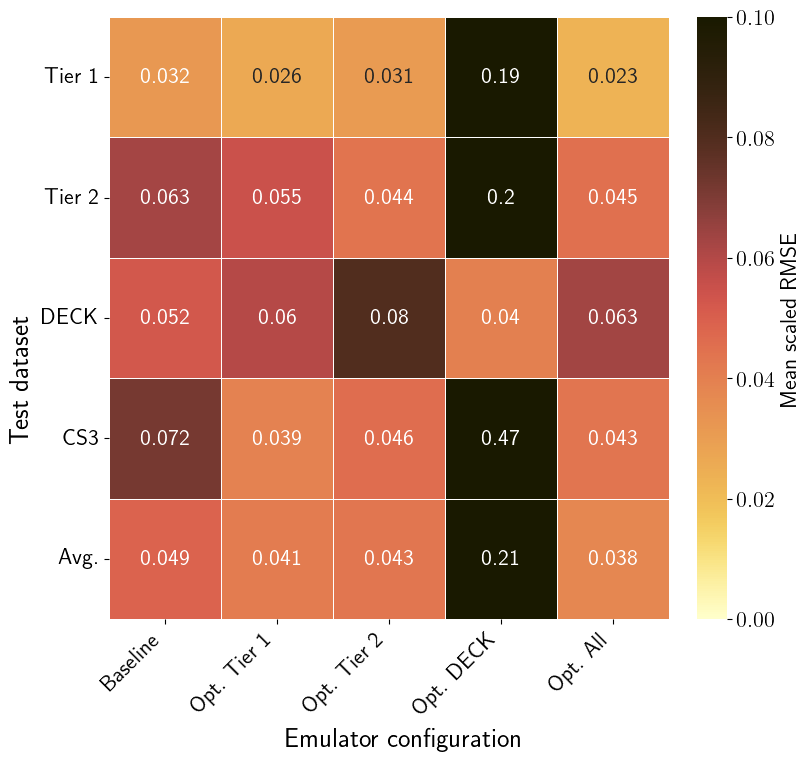

In [105]:
train_scenarios = ['Opt. Tier 1', 'Opt. Tier 2', 'Opt. DECK', 'Opt. All']
test_scenarios = ['Tier 1', 'Tier 2', 'DECK', 'CS3']
weights = [7, 5, 2, 2]
vmax = 0.1
plot_single_heatmap(baseline_results, optimal_results, train_scenarios, test_scenarios, training_paths, weights, vmax, save=True)

In [104]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from cmcrameri import cm

def plot_single_heatmap(baseline_results: dict,
                        optimized_results: dict,
                        train_scenarios: list[str],
                        test_scenarios: list[str],
                        training_paths: list[str],
                        weights: list[int],
                        vmax: float,
                        cmap: str = cm.lajolla_r,
                        long_title: str = '',
                        save: bool=False) -> None:
  """
  Draws a comparison heatmap: Baseline vs Optimized results.

  Rows (Y-axis): Test Sets
  Cols (X-axis): Baseline (Col 0) + Optimized Results per Training Path (Cols 1..N)

  Parameters
  ----------
  baseline_results : dict
    Errors indexed as baseline_results[test_set]['mean'].
  optimized_results : dict
    Errors indexed as optimized_results[training_path]['metrics'][test_set]['mean'].
  train_scenarios : list[str]
    List of training path keys (determines columns 1 to N).
  test_scenarios : list[str]
    List of test set keys (determines rows).
  ax : matplotlib.axes.Axes
    Target axis for the heat-map.
  vmax : float
    Colour-scale maximum (min is fixed at 0).
  cmap : str, optional
    Matplotlib/SNS colour-map (default "Reds").
  long_title : str, optional
    Sub-plot title.
  add_cbar : bool, optional
    Add colour-bar on this axis when True.

  Returns
  -------
  None
  """
  # Dimensions: Rows = 1 (Avg.) + N (Test Sets), Columns = 1 (Baseline) + N (Training Scenarios)
  n_test = len(test_scenarios)
  n_rows = 1 + n_test
  n_cols = 1 + len(train_scenarios)

  fig, ax = plt.subplots(figsize=(8 * n_cols / 5, 6 * n_rows / 4), sharex='col', constrained_layout=True)

  # Instantiate data array
  data = np.empty((n_rows, n_cols))

  # --- Fill Column 0: Baseline Results ---
  for i, scen_test in enumerate(test_scenarios):
    try:
      # Access: baseline_results[test_set]['mean']
      value = baseline_results[scen_test]['mean']
    except KeyError:
      value = np.nan
    data[i, 0] = value

  # --- Fill Columns 1 to N: Optimized Results ---
  for j, path in enumerate(training_paths):
    col_idx = j + 1  # Offset by 1 because col 0 is baseline
    for i, scen_test in enumerate(test_scenarios):
      try:
        value = optimized_results[path]['metrics'][scen_test]['mean']
      except KeyError:
        value = np.nan
      data[i, col_idx] = value

  w_arr = np.array(weights)
  for col in range(n_cols):
    # Slice the column data corresponding to the test scenarios (exclude the last empty row)
    col_data = data[:n_test, col]

    # Calculate weighted average
    # Note: If col_data contains NaNs, the result will be NaN.
    # Use np.ma.average if you wish to ignore NaNs, but standard np.average is used here.
    try:
      avg_val = np.average(col_data, weights=w_arr)
    except Exception:
      avg_val = np.nan

    data[n_test, col] = avg_val

  # Plot the heatmap
  sns.heatmap(
    data,
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=vmax,
    linewidth=0.5,
    annot=True,
    fmt=".2g",
    cbar=True,
    cbar_kws={"label": r"Mean scaled RMSE"}
  )

  # Configure labels and title
  ax.set_title(long_title)

  # Generate dynamic labels based on inputs
  # X-labels: "Baseline" followed by the training scenario names
  x_tick_labels = ['Baseline'] + train_scenarios
  # Y-labels: The test scenario names
  y_tick_labels = test_scenarios + ['Avg.']
  ax.set_xticklabels(x_tick_labels, rotation=45, ha="right")
  ax.set_yticklabels(y_tick_labels, rotation=0) # Typically horizontal for Y-axis looks better

  fig.supxlabel('Emulator configuration')
  fig.supylabel('Test dataset')

  if save:
    plt.savefig('Figures/heatmap_co2.pdf')

  return